In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

**Load Dataset**

In [3]:
df = pd.read_csv('Credit Card Fraud Detection\creditcard.csv')

**Display Dataset**

In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


**Dataset Information**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

**Check Missing Values**

In [6]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

**Dataset Statistics**

In [7]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


**Check Class Distribution**

In [8]:
print(df['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


**Visualize Fraud vs Genuine Transactions**

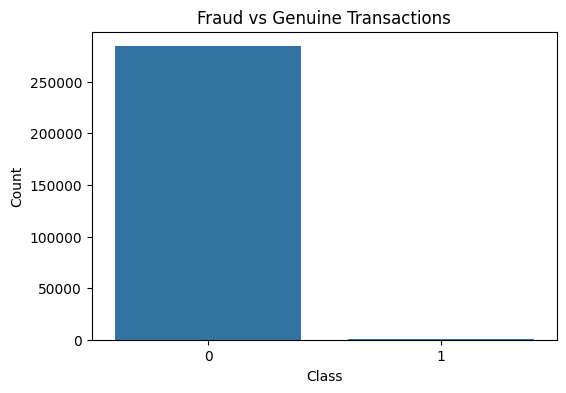

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)

plt.title('Fraud vs Genuine Transactions')
plt.xlabel('Class')
plt.ylabel('Count')

plt.show()

**Correlation Heatmap**

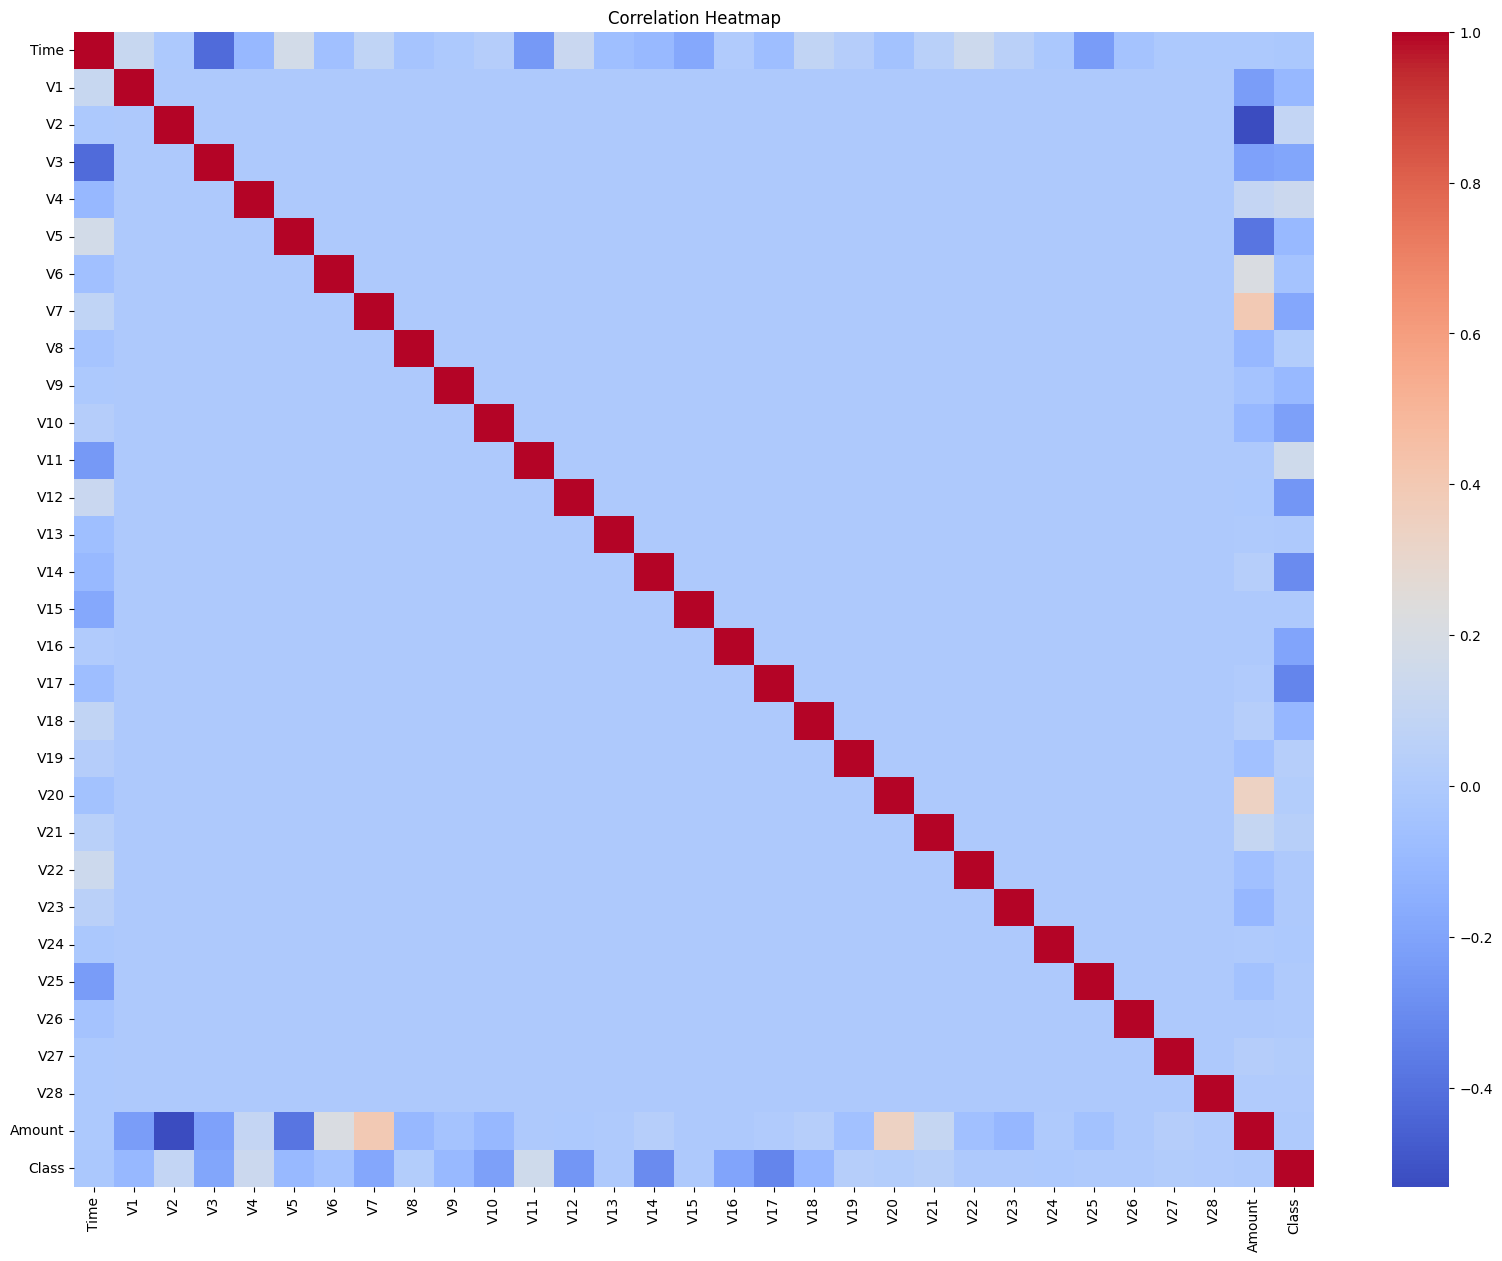

In [10]:
plt.figure(figsize=(20,15))
sns.heatmap(df.corr(), cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

**Feature Scaling**

In [11]:
scaler = StandardScaler()

df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time'] = scaler.fit_transform(df[['Time']])

**Define Features and Target**

In [12]:
X = df.drop('Class', axis=1)
y = df['Class']

**Handle Imbalanced Dataset Using SMOTE**

In [13]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(y_resampled.value_counts())

Class
0    284315
1    284315
Name: count, dtype: int64


**Split Dataset**

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42
)

**Train Logistic Regression Model**

In [15]:
lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


**Logistic Regression Predictions**

In [17]:
y_pred_lr = lr_model.predict(X_test)

**Logistic Regression Evaluation**

In [18]:
print('Accuracy Score:', accuracy_score(y_test, y_pred_lr))

print('\nClassification Report:\n')
print(classification_report(y_test, y_pred_lr))

Accuracy Score: 0.9489035049153228

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.98      0.95     56750
           1       0.97      0.92      0.95     56976

    accuracy                           0.95    113726
   macro avg       0.95      0.95      0.95    113726
weighted avg       0.95      0.95      0.95    113726



**Logistic Regression Confusion Matrix**

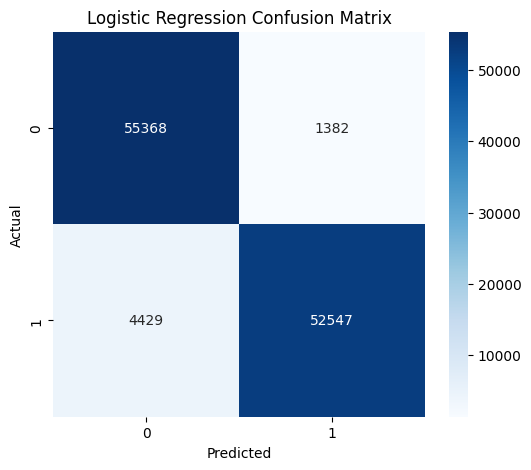

In [19]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

**Train Random Forest Model**

In [20]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


**Random Forest Predictions**

In [21]:
y_pred_rf = rf_model.predict(X_test)

**Random Forest Evaluation**

In [22]:
print('Accuracy Score:', accuracy_score(y_test, y_pred_rf))

print('\nClassification Report:\n')
print(classification_report(y_test, y_pred_rf))

Accuracy Score: 0.999903276295658

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56750
           1       1.00      1.00      1.00     56976

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726



**Random Forest Confusion Matrix**

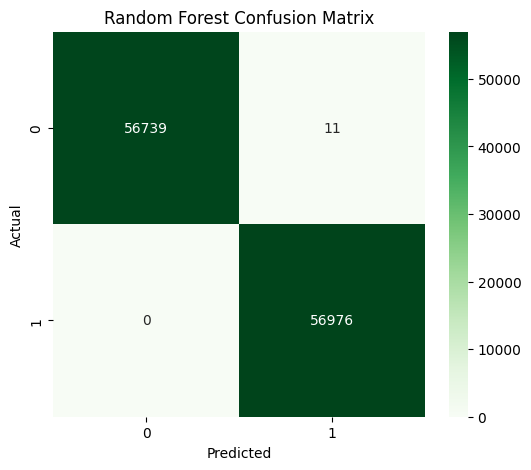

In [23]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

**ROC-AUC Score**

In [24]:
roc_score = roc_auc_score(y_test, y_pred_rf)

print('ROC-AUC Score:', roc_score)

ROC-AUC Score: 0.9999030837004405


**Feature Importance**

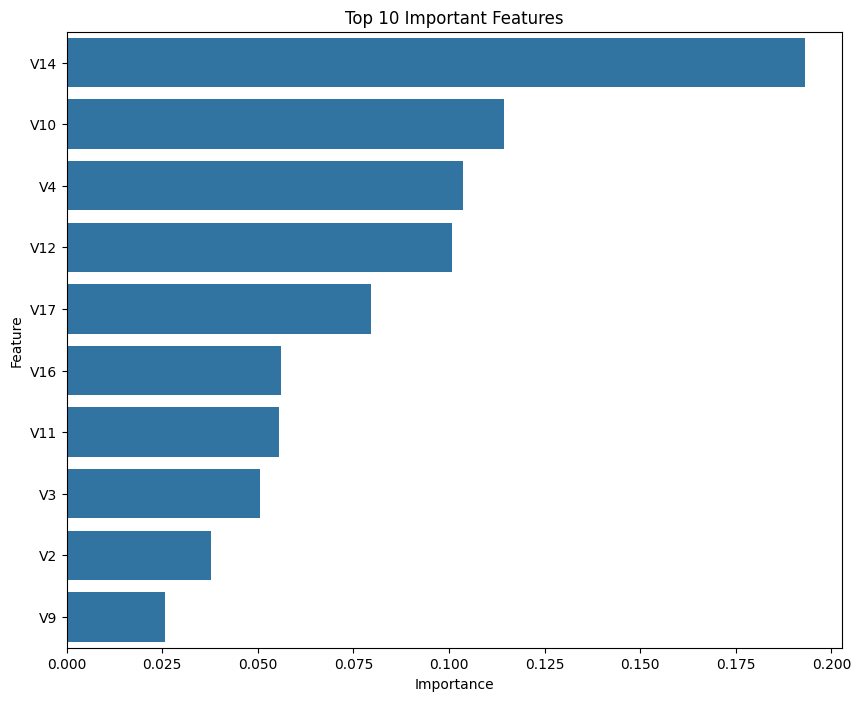

In [25]:
importance = rf_model.feature_importances_
features = X.columns

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10))

plt.title('Top 10 Important Features')
plt.show()

**Save Model**

In [26]:
import pickle

pickle.dump(rf_model, open('fraud_detection_model.pkl', 'wb'))

**Load Saved Model**

In [27]:
loaded_model = pickle.load(open('fraud_detection_model.pkl', 'rb'))

**Make Sample Prediction**

In [28]:
sample_data = X_test.iloc[0].values.reshape(1, -1)

prediction = loaded_model.predict(sample_data)

if prediction[0] == 1:
    print('Fraudulent Transaction Detected')
else:
    print('Genuine Transaction')

Fraudulent Transaction Detected


In [78]:
# Fraudulent Transaction 
# sample_data = X_test.iloc[1].values.reshape(1, -1)

# Genuine Transaction
# sample_data = df[df['Class'] == 0].drop('Class', axis=1).iloc[0].values.reshape(1, -1)


random_index = X_test.sample().index[0]
sample_data = X_test.loc[random_index].values.reshape(1, -1)

# Prediction
prediction = loaded_model.predict(sample_data)

# Prediction Probability
prediction_prob = loaded_model.predict_proba(sample_data)

print("Prediction Result:")

if prediction[0] == 1:
    print("Fraudulent Transaction Detected")
    print(f"Fraud Probability: {prediction_prob[0][1] * 100:.2f}%")
else:
    print("Genuine Transaction")
    print(f"Genuine Probability: {prediction_prob[0][0] * 100:.2f}%")

Prediction Result:
Genuine Transaction
Genuine Probability: 100.00%


**Model Comparison**

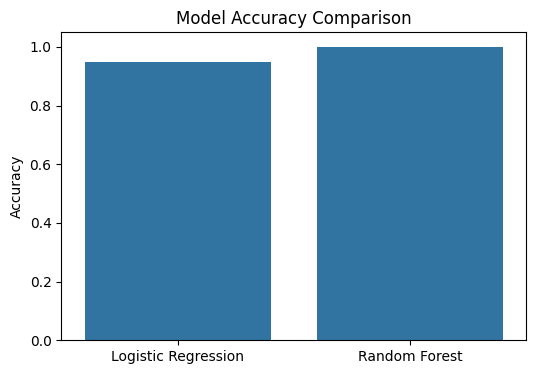

In [29]:
models = ['Logistic Regression', 'Random Forest']
accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_rf)
]

plt.figure(figsize=(6,4))
sns.barplot(x=models, y=accuracies)

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')

plt.show()

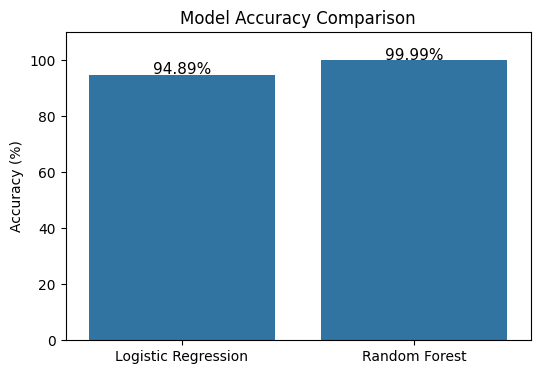

In [30]:
models = ['Logistic Regression', 'Random Forest']

accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_rf)
]

# Convert to percentage
accuracies_percent = [acc * 100 for acc in accuracies]

plt.figure(figsize=(6,4))

ax = sns.barplot(x=models, y=accuracies_percent)

# Add percentage labels
for i, v in enumerate(accuracies_percent):
    ax.text(i, v + 0.2, f"{v:.2f}%", ha='center', fontsize=11)

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 110)

plt.show()